# LAB 02 - N-gram Language Models: Experiments

Notebook này dùng implementation trong `ngram_lm.py` (tự cài đặt, không dùng thư viện LM).

Nội dung:
1. Chuẩn bị corpus, chia train / validation / test
2. Experiment 1 - Corpus statistics & frequency distribution (mục 13)
3. Vocabulary & train các model
4. Log probability vs underflow (mục 15)
5. Experiment 2 - MLE vs Laplace smoothing (mục 16)
6. Experiment 3 - Perplexity Unigram / Bigram / Trigram (mục 19)
7. Context length & unseen n-gram, ảnh hưởng corpus size (mục 23)
8. Application - Next-word prediction (mục 20)
9. Application - Sentence ranking (mục 21)
10. Dữ liệu cho error analysis (mục 22)
11. Lưu `results.csv`

## 0. Setup

In [1]:
import json
import math
import random
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from ngram_lm import (
    UNK, NGramLanguageModel, build_vocabulary, count_ngrams,
    preprocess_documents, replace_oov, tokenize,
)

CORPUS_PATH = Path(r"E:/hus/nlp/c4-train.00000-of-01024-30K.json/c4-train.00000-of-01024-30K.json")
N_DOCS = 10_000   # đề yêu cầu corpus nhỏ trước: 10K-30K documents
MIN_COUNT = 2     # từ xuất hiện < MIN_COUNT lần trong train -> <unk>
SEED = 42

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Chuẩn bị corpus

- Đọc `N_DOCS` document đầu tiên của C4, xáo trộn với seed cố định.
- Chia theo document 80 / 10 / 10 để các câu của cùng một document không bị rơi vào cả train và test.
- Mỗi document được tách câu (theo `. ! ?` và xuống dòng), tokenize bằng lowercase + regex chữ/số.

In [2]:
with open(CORPUS_PATH, encoding="utf-8") as f:
    docs = [json.loads(line)["text"] for _, line in zip(range(N_DOCS), f)]
random.Random(SEED).shuffle(docs)

n_train = int(0.8 * len(docs))
n_valid = int(0.1 * len(docs))
split_docs = {
    "train": docs[:n_train],
    "valid": docs[n_train:n_train + n_valid],
    "test": docs[n_train + n_valid:],
}
splits = {name: preprocess_documents(d) for name, d in split_docs.items()}
train, valid, test = splits["train"], splits["valid"], splits["test"]

print({name: len(s) for name, s in splits.items()}, "sentences")
print("Ví dụ:", train[0][:20])

{'train': 166282, 'valid': 21471, 'test': 20201} sentences
Ví dụ: ['this', 'is', 'one', 'of', 'those', 'things', "i've", 'been', 'meaning', 'to', 'make', 'for', 'ages', 'but', 'never', 'quite', 'got', 'round', 'to', 'it']


## 2. Experiment 1 - Corpus statistics

In [3]:
def split_stats(name, n_docs, sents):
    tokens = [w for s in sents for w in s]
    return {
        "split": name,
        "documents": n_docs,
        "sentences": len(sents),
        "tokens": len(tokens),
        "vocabulary_size": len(set(tokens)),
        "avg_sentence_len": len(tokens) / len(sents),
    }

stats_df = pd.DataFrame(
    [split_stats(name, len(split_docs[name]), splits[name]) for name in splits]
    + [split_stats("all", len(docs), train + valid + test)]
)
stats_df

,split,documents,sentences,tokens,vocabulary_size,avg_sentence_len
0,train,8000,166282,2893053,88963,17.3985
1,valid,1000,21471,374637,28344,17.4485
2,test,1000,20201,366753,27652,18.1552
3,all,10000,207954,3634443,101795,17.4771


In [4]:
# Đếm n-gram trên train (từ gốc, chưa map <unk>; có padding <s> / </s>)
raw_counts = {n: count_ngrams(train, n) for n in (1, 2, 3)}

ngram_stats = []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    counts = raw_counts[n]
    singletons = sum(1 for c in counts.values() if c == 1)
    ngram_stats.append({
        "model": name,
        "total_ngrams": sum(counts.values()),
        "unique_ngrams": len(counts),
        "singletons (count=1)": singletons,
        "singleton_ratio": singletons / len(counts),
    })
ngram_stats_df = pd.DataFrame(ngram_stats)
ngram_stats_df

,model,total_ngrams,unique_ngrams,singletons (count=1),singleton_ratio
0,Unigram,3059335,88964,40628,0.4567
1,Bigram,3059335,1030106,753126,0.7311
2,Trigram,3059335,2136974,1877470,0.8786


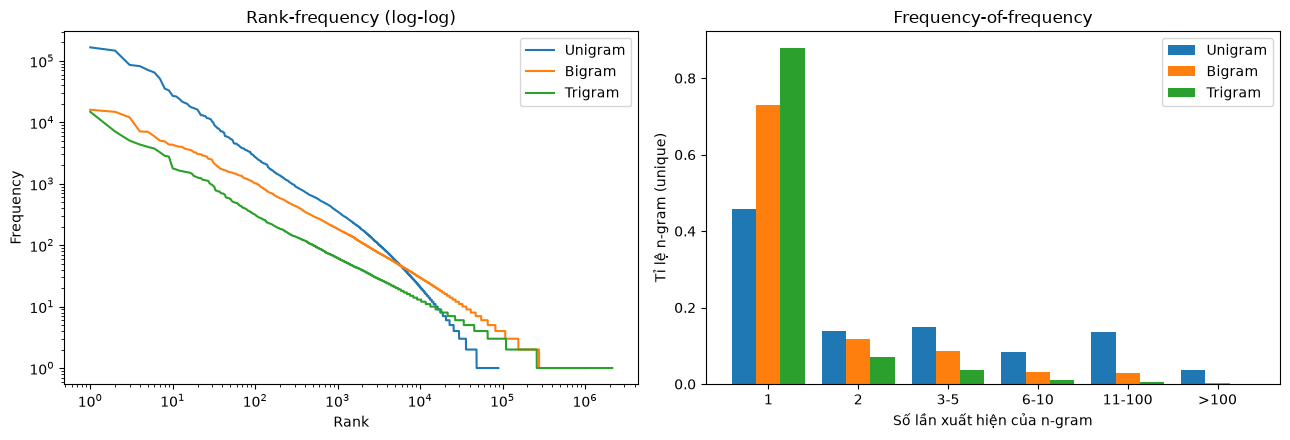

Top 10 unigram: [(('</s>',), 166282), (('the',), 147257), (('and',), 86159), (('to',), 82150), (('of',), 71216), (('a',), 64841), (('in',), 51324), (('is',), 35454), (('for',), 33026), (('you',), 26947)]
Top 10 bigram: [(('of', 'the'), 16015), (('<s>', 'the'), 14830), (('in', 'the'), 12047), (('<s>', 'i'), 7101), (('to', 'the'), 7024), (('on', 'the'), 5913), (('<s>', 'this'), 5033), (('for', 'the'), 4902), (('<s>', 'we'), 4351), (('and', 'the'), 4319)]
Top 10 trigram: [(('<s>', '<s>', 'the'), 14830), (('<s>', '<s>', 'i'), 7101), (('<s>', '<s>', 'this'), 5033), (('<s>', '<s>', 'we'), 4351), (('<s>', '<s>', 'it'), 3987), (('<s>', '<s>', 'in'), 3738), (('<s>', '<s>', 'if'), 3250), (('<s>', '<s>', 'you'), 2856), (('<s>', '<s>', 'a'), 2759), (('<s>', '<s>', 'and'), 1781)]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    freqs = sorted(raw_counts[n].values(), reverse=True)
    axes[0].loglog(range(1, len(freqs) + 1), freqs, label=name)
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Rank-frequency (log-log)")
axes[0].legend()

buckets = ["1", "2", "3-5", "6-10", "11-100", ">100"]
def bucket(c):
    if c == 1: return "1"
    if c == 2: return "2"
    if c <= 5: return "3-5"
    if c <= 10: return "6-10"
    if c <= 100: return "11-100"
    return ">100"

width = 0.27
for i, (n, name) in enumerate([(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]):
    counts = raw_counts[n]
    dist = Counter(bucket(c) for c in counts.values())
    ratios = [dist[b] / len(counts) for b in buckets]
    axes[1].bar([x + (i - 1) * width for x in range(len(buckets))], ratios, width, label=name)
axes[1].set_xticks(range(len(buckets)))
axes[1].set_xticklabels(buckets)
axes[1].set_xlabel("Số lần xuất hiện của n-gram")
axes[1].set_ylabel("Tỉ lệ n-gram (unique)")
axes[1].set_title("Frequency-of-frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Top 10 unigram:", raw_counts[1].most_common(10))
print("Top 10 bigram:", raw_counts[2].most_common(10))
print("Top 10 trigram:", raw_counts[3].most_common(10))

Nhận xét - corpus statistics và phân phối tần suất (đối chiếu Prediction 1, 2):

- Corpus: 10,000 document, 207,954 câu, 3,634,443 token, vocabulary 101,795 từ. Train: 8,000 document, 166,282 câu, 2,893,053 token, 88,963 từ.
- Vocabulary không phụ thuộc n. Tổng số n-gram token của cả ba bậc bằng nhau (3,059,335 = số token + số EOS) nhưng số n-gram unique tăng mạnh: 88,964 → 1,030,106 → 2,136,974.
- Tỉ lệ singleton tăng 45.7% → 73.1% → 87.9%: n càng lớn thì phần lớn n-gram chỉ gặp một lần, xác suất ước lượng từ các n-gram này kém tin cậy.
- Đồ thị rank-frequency gần tuyến tính trên thang log-log (dạng Zipf): một số ít n-gram rất phổ biến (the, of the, BOS BOS the) và một đuôi dài n-gram hiếm. Đường trigram thấp và dài hơn, tức phân phối bị trải mỏng hơn.

In [6]:
del raw_counts  # giải phóng bộ nhớ

## 3. Vocabulary & train các model

- Vocabulary được build chỉ từ train, dùng chung cho mọi model để perplexity so sánh được (cùng V, cùng cách map UNK).
- Bản Laplace dùng chung counts với bản MLE (`with_smoothing`), chỉ khác công thức xác suất.

In [7]:
vocab = build_vocabulary(train, MIN_COUNT)
print(f"V = {len(vocab):,} (min_count = {MIN_COUNT}, gồm </s> và <unk>)")

for name in ("valid", "test"):
    toks = [w for s in splits[name] for w in s]
    oov = sum(1 for w in toks if w not in vocab)
    print(f"OOV rate {name}: {oov / len(toks):.2%}")

V = 48,337 (min_count = 2, gồm </s> và <unk>)
OOV rate valid: 3.84%
OOV rate test: 3.50%


In [8]:
MODEL_NAMES = {1: "Unigram", 2: "Bigram", 3: "Trigram"}
models = {}
for n, name in MODEL_NAMES.items():
    t0 = time.time()
    mle = NGramLanguageModel(n, "mle").fit(train, vocabulary=vocab)
    models[(name, "mle")] = mle
    models[(name, "laplace")] = mle.with_smoothing("laplace")
    print(f"{name}: {len(mle.ngram_counts):,} n-gram, "
          f"{len(mle.context_counts):,} context, {time.time() - t0:.1f}s")

Unigram: 48,337 n-gram, 1 context, 2.5s


Bigram: 970,945 n-gram, 48,337 context, 4.9s


Trigram: 2,107,942 n-gram, 950,084 context, 4.8s


## 4. Log probability vs numerical underflow (mục 15)

In [9]:
bigram_lap = models[("Bigram", "laplace")]
long_sent = max(test, key=len)
print("Độ dài câu:", len(long_sent), "token")
print("sentence_probability     :", bigram_lap.sentence_probability(long_sent))
print("sentence_log_probability :", bigram_lap.sentence_log_probability(long_sent))
print("Số double dương nhỏ nhất ~ 5e-324, tức log ~", math.log(5e-324))

Độ dài câu: 191 token
sentence_probability     : 0.0
sentence_log_probability : -1558.5864625427876
Số double dương nhỏ nhất ~ 5e-324, tức log ~ -744.4400719213812


Nhận xét - tại sao log probability tránh được underflow:

Xác suất câu là tích của nhiều số nhỏ hơn 1 nên giảm theo cấp số nhân theo độ dài. Với câu 191 token, log P = -1558.6, tức P ≈ e^(-1558.6), nhỏ hơn nhiều so với số double dương nhỏ nhất (≈ 5e-324, log ≈ -744.4), nên phép nhân trực tiếp bị underflow về 0.0. Lấy log biến tích thành tổng, mỗi log P(w_t|context) chỉ cỡ vài đến vài chục đơn vị âm nên tổng của hàng trăm số hạng vẫn nằm trong phạm vi biểu diễn của float. Vì log đồng biến nên thứ tự so sánh giữa các câu không đổi.

## 5. Experiment 2 - MLE vs Laplace smoothing (mục 16)

`zero_rate` = tỉ lệ token có P = 0 (khi đó perplexity = ∞).

In [10]:
rows = []
for (name, sm), model in models.items():
    for split in ("train", "valid", "test"):
        t0 = time.time()
        r = model.evaluate(splits[split])
        rows.append({"model": name, "smoothing": sm, "split": split, **r})
    print(f"Evaluated {name} {sm} ({time.time() - t0:.1f}s cho split cuối)")
ppl_df = pd.DataFrame(rows)

def ppl_table(df):
    table = df.pivot_table(index=["model", "smoothing"], columns="split",
                           values=["perplexity", "zero_rate"], sort=False)
    return table.reindex(columns=["train", "valid", "test"], level=1)

Evaluated Unigram mle (0.4s cho split cuối)


Evaluated Unigram laplace (0.4s cho split cuối)


Evaluated Bigram mle (0.6s cho split cuối)


Evaluated Bigram laplace (0.6s cho split cuối)


Evaluated Trigram mle (0.6s cho split cuối)


Evaluated Trigram laplace (0.7s cho split cuối)


In [11]:
exp2 = ppl_df[ppl_df["model"].isin(["Bigram", "Trigram"])]
ppl_table(exp2)

perplexity                         zero_rate              
split                   train       valid        test     train  valid   test
model   smoothing                                                            
Bigram  mle          125.3444         inf         inf    0.0000 0.2424 0.2368
        laplace    3,111.5794  3,717.1793  3,589.6924    0.0000 0.0000 0.0000
Trigram mle            9.8952         inf         inf    0.0000 0.6422 0.6373
        laplace   11,887.7585 19,809.8997 19,612.2769    0.0000 0.0000 0.0000

Nhận xét - MLE vs Laplace, tại sao kết quả lại như vậy:

- MLE: train PPL thấp (bigram 125.3, trigram 9.9) vì model gán đúng tần suất đã thấy trong train. Trên valid/test PPL = ∞ vì 24.2% (bigram) và 64.2% (trigram) token nằm trong n-gram chưa gặp, MLE cho P = 0.
- Laplace: không còn zero nên valid/test PPL hữu hạn, nhưng train PPL tăng vọt (bigram 125 → 3,112, trigram 9.9 → 11,888). Nguyên nhân là mỗi context được cộng V = 48,337 pseudo-count trong khi phần lớn context có C(h) nhỏ, nên hầu hết khối xác suất bị chuyển sang các từ chưa gặp. Ví dụ context "to transition" có C(h) = 6: MLE cho P(from|to transition) = 2/6 = 0.333, Laplace chỉ còn 3/48,343 ≈ 6.2e-5.
- Trigram bị ảnh hưởng nặng hơn bigram vì context 2 từ có C(h) nhỏ hơn nhiều (950,084 context cho khoảng 3 triệu token), nên trigram Laplace còn tệ hơn cả unigram.
- Valid và test cho kết quả gần như nhau nên kết luận ổn định. Laplace giải quyết được zero probability nhưng quá thô khi V lớn, cần add-k với k nhỏ, backoff hoặc interpolation.

## 6. Experiment 3 - Perplexity Unigram / Bigram / Trigram (mục 19)

In [12]:
ppl_table(ppl_df)

perplexity                         zero_rate              
split                   train       valid        test     train  valid   test
model   smoothing                                                            
Unigram mle        1,434.1646  1,233.4193  1,188.2097    0.0000 0.0000 0.0000
        laplace    1,436.1593  1,238.0577  1,193.0680    0.0000 0.0000 0.0000
Bigram  mle          125.3444         inf         inf    0.0000 0.2424 0.2368
        laplace    3,111.5794  3,717.1793  3,589.6924    0.0000 0.0000 0.0000
Trigram mle            9.8952         inf         inf    0.0000 0.6422 0.6373
        laplace   11,887.7585 19,809.8997 19,612.2769    0.0000 0.0000 0.0000

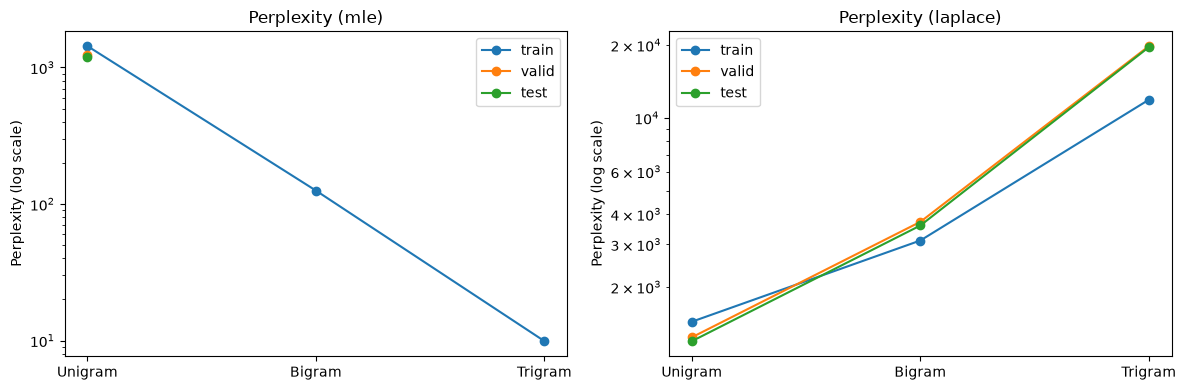

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sm in zip(axes, ("mle", "laplace")):
    sub = ppl_df[ppl_df["smoothing"] == sm]
    for split in ("train", "valid", "test"):
        s = sub[sub["split"] == split]
        # inf không vẽ được -> bỏ qua
        s = s[s["perplexity"] != float("inf")]
        ax.plot(s["model"], s["perplexity"], marker="o", label=split)
    ax.set_yscale("log")
    ax.set_title(f"Perplexity ({sm})")
    ax.set_ylabel("Perplexity (log scale)")
    ax.legend()
plt.tight_layout()
plt.show()

Nhận xét - training perplexity, validation/test, dấu hiệu overfitting:

- Training perplexity (MLE) giảm mạnh khi tăng n: 1,434 → 125 → 9.9, vì context dài hơn làm phân phối P(w|h) nhọn hơn, nhiều context 2 từ trong train chỉ có một tiếp diễn nên P ≈ 1 (model gần như ghi nhớ train).
- Validation/test không cải thiện: bigram/trigram MLE có PPL = ∞ do n-gram chưa gặp, với Laplace valid PPL tăng theo n (1,238 → 3,717 → 19,810). Unigram có valid/test PPL thấp hơn train (1,233 so với 1,434) chủ yếu vì các từ lạ của valid/test được gộp vào UNK, token có xác suất khá cao.
- Dấu hiệu overfitting: khoảng cách giữa train và valid/test tăng theo n (trigram MLE: 9.9 so với ∞; tỉ lệ valid/train của Laplace: 0.86 ở unigram, 1.19 ở bigram, 1.67 ở trigram).
- Corpus size (mục 7): tăng train từ 10% lên 100% làm valid PPL Laplace của bigram giảm 11,605 → 3,717, trigram giảm 32,088 → 19,810. Model bậc cao hưởng lợi nhiều nhất từ dữ liệu nhưng với 8,000 document vẫn chưa đủ.

## 7. Context length: số n-gram & unseen n-gram (mục 23)

In [14]:
unseen_rows = []
for n, name in MODEL_NAMES.items():
    model = models[(name, "mle")]
    for split in ("valid", "test"):
        r = model.count_unseen_ngrams(splits[split])
        unseen_rows.append({"model": name, "split": split,
                            "train_unique_ngrams": len(model.ngram_counts), **r})
unseen_df = pd.DataFrame(unseen_rows)
unseen_df

,model,split,train_unique_ngrams,total_ngrams,unseen_ngrams,unseen_rate,unseen_types
0,Unigram,valid,48337,396108,0,0.0000,0
1,Unigram,test,48337,386954,0,0.0000,0
2,Bigram,valid,970945,396108,96021,0.2424,84169
3,Bigram,test,970945,386954,91629,0.2368,82221
4,Trigram,valid,2107942,396108,254391,0.6422,237667
5,Trigram,test,2107942,386954,246618,0.6373,234440


### Ảnh hưởng của corpus size

In [15]:
FRACTIONS = [0.1, 0.25, 0.5, 1.0]
size_rows = []
for frac in FRACTIONS:
    sub_train = train[:int(frac * len(train))]
    for n, name in MODEL_NAMES.items():
        if frac == 1.0:
            model = models[(name, "laplace")]
        else:
            model = NGramLanguageModel(n, "laplace").fit(sub_train, vocabulary=vocab)
        size_rows.append({
            "train_fraction": frac,
            "train_sentences": len(sub_train),
            "model": name,
            "smoothing": "laplace",
            "train_ppl": model.perplexity(sub_train),
            "valid_ppl": model.perplexity(valid),
            "valid_unseen_rate": model.count_unseen_ngrams(valid)["unseen_rate"],
        })
        del model
size_df = pd.DataFrame(size_rows)
size_df

,train_fraction,train_sentences,model,smoothing,train_ppl,valid_ppl,valid_unseen_rate
0,0.1000,16628,Unigram,laplace,"1,368.4956","1,377.1499",0.0365
1,0.1000,16628,Bigram,laplace,"7,510.1636","11,604.5933",0.4568
2,0.1000,16628,Trigram,laplace,"16,594.0843","32,087.9727",0.8092
3,0.2500,41570,Unigram,laplace,"1,382.3675","1,293.2507",0.0146
4,0.2500,41570,Bigram,laplace,"5,336.6572","7,461.5778",0.3630
5,0.2500,41570,Trigram,laplace,"14,844.8517","27,270.1237",0.7464
6,0.5000,83141,Unigram,laplace,"1,404.9989","1,260.2469",0.0047
7,0.5000,83141,Bigram,laplace,"4,094.8480","5,267.5288",0.2991
8,0.5000,83141,Trigram,laplace,"13,458.8347","23,521.5817",0.6958
9,1.0000,166282,Unigram,laplace,"1,436.1593","1,238.0577",0.0000


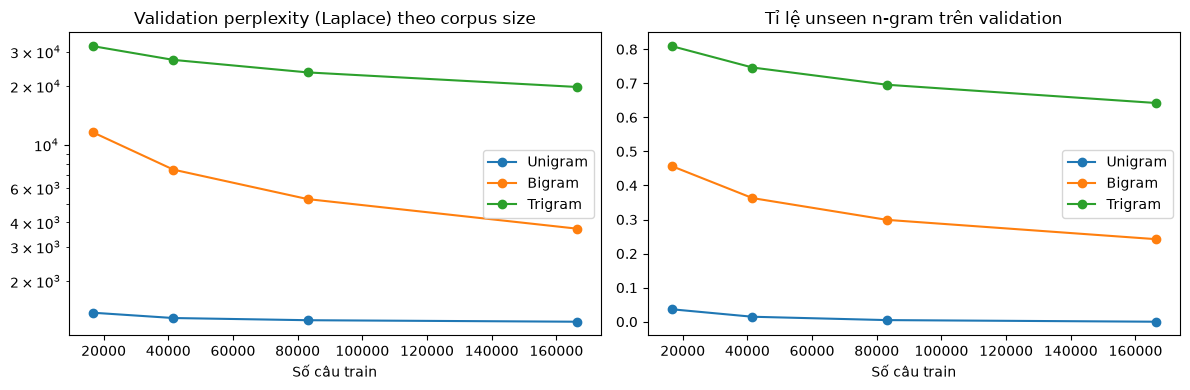

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in MODEL_NAMES.values():
    s = size_df[size_df["model"] == name]
    axes[0].plot(s["train_sentences"], s["valid_ppl"], marker="o", label=name)
    axes[1].plot(s["train_sentences"], s["valid_unseen_rate"], marker="o", label=name)
axes[0].set_title("Validation perplexity (Laplace) theo corpus size")
axes[0].set_yscale("log")
axes[1].set_title("Tỉ lệ unseen n-gram trên validation")
for ax in axes:
    ax.set_xlabel("Số câu train")
    ax.legend()
plt.tight_layout()
plt.show()

Nhận xét - context dài hơn có luôn tốt hơn không, tác động của corpus size:

- Số n-gram unique trong train (sau khi map UNK): 48,337 → 970,945 → 2,107,942. Tỉ lệ n-gram chưa gặp trên validation: 0% → 24.2% → 64.2%, trên test: 0% → 23.7% → 63.7%.
- Context dài hơn không luôn tốt hơn: train PPL giảm theo n nhưng valid/test PPL thì ngược lại (MLE: ∞, Laplace: 1,238 → 3,717 → 19,810). Với lượng dữ liệu này, lợi ích của thêm ngữ cảnh bị lấn át bởi sparsity.
- Corpus size: tăng dữ liệu làm giảm tỉ lệ unseen (trigram 80.9% → 64.2%, bigram 45.7% → 24.2%) và valid PPL của bigram/trigram giảm rõ rệt, unigram gần như không đổi (1,377 → 1,238). Đường cong vẫn đang đi xuống nên thêm dữ liệu sẽ tiếp tục có lợi, nhất là cho trigram.

## 8. Application - Next-word prediction (mục 20)

- Dùng xác suất MLE để xếp hạng (với Laplace thứ tự các từ đã gặp không đổi vì `(c+1)/(C+V)` đồng biến theo `c`).
- Actual next word: từ xuất hiện nhiều nhất ngay sau context trong test set (nếu context có trong test).

In [17]:
CONTEXTS = [
    "the cat",
    "natural language",
    "machine learning",
    "in the",
    "one of the",
    "i would like to",
    "the united states",
    "thank you for",
]

def actual_next_words(sentences, context):
    ctx = tokenize(context)
    k = len(ctx)
    nxt = Counter()
    for s in sentences:
        for i in range(len(s) - k):
            if s[i:i + k] == ctx:
                nxt[s[i + k]] += 1
    return nxt

next_word_rows = []
for context in CONTEXTS:
    actual = actual_next_words(test, context)
    actual_word = actual.most_common(1)[0][0] if actual else None
    for name in ("Bigram", "Trigram"):
        top = models[(name, "mle")].next_word_distribution(context, top_k=5)
        next_word_rows.append({
            "context": context,
            "model": name,
            "prediction": top[0][0] if top else None,
            "prediction_prob": top[0][1] if top else None,
            "top5": ", ".join(f"{w} ({p:.3f})" for w, p in top) if top else "(context chưa gặp)",
            "actual_next_word": actual_word,
            "actual_count_in_test": actual[actual_word] if actual_word else 0,
            "in_top5": actual_word in [w for w, _ in top] if actual_word else None,
        })
next_word_df = pd.DataFrame(next_word_rows)
with pd.option_context("display.max_colwidth", 120):
    display(next_word_df)

,context,model,prediction,prediction_prob,top5,actual_next_word,actual_count_in_test,in_top5
0,the cat,Bigram,house,0.1156,"house (0.116), to (0.064), and (0.052), town (0.046), queen (0.035)",had,1,False
1,the cat,Trigram,queen,0.2941,"queen (0.294), house (0.118), that (0.059), home (0.059), houses (0.059)",had,1,False
2,natural language,Bigram,</s>,0.1335,"</s> (0.133), and (0.082), of (0.059), that (0.023), is (0.021)",processing,2,False
3,natural language,Trigram,</s>,0.5000,"</s> (0.500), 1980 (0.500)",processing,2,False
4,machine learning,Bigram,</s>,0.0967,"</s> (0.097), and (0.072), to (0.062), about (0.059), in (0.048)",models,2,False
5,machine learning,Trigram,and,0.1463,"and (0.146), based (0.122), to (0.098), </s> (0.098), approaches (0.098)",models,2,False
6,in the,Bigram,most,0.0105,"most (0.011), first (0.010), best (0.010), same (0.009), world (0.007)",world,44,True
7,in the,Trigram,world,0.0217,"world (0.022), past (0.015), first (0.011), united (0.010), future (0.010)",world,44,True
8,one of the,Bigram,most,0.0105,"most (0.011), first (0.010), best (0.010), same (0.009), world (0.007)",most,32,True
9,one of the,Trigram,most,0.0200,"most (0.020), best (0.011), world (0.008), year (0.008), time (0.006)",most,32,True


In [18]:
# Hiển thị dạng giống đề bài
for context in ["the cat", "natural language", "machine learning"]:
    print(f"Input: {context}")
    for name in ("Bigram", "Trigram"):
        print(f"  [{name}]")
        top = models[(name, "mle")].next_word_distribution(context, top_k=5)
        if not top:
            print("    (context chưa gặp trong train)")
        for i, (w, p) in enumerate(top, 1):
            print(f"    {i}. {w:<12} {p:.2f}")

Input: the cat
  [Bigram]
    1. house        0.12
    2. to           0.06
    3. and          0.05
    4. town         0.05
    5. queen        0.03
  [Trigram]
    1. queen        0.29
    2. house        0.12
    3. that         0.06
    4. home         0.06
    5. houses       0.06
Input: natural language
  [Bigram]
    1. </s>         0.13
    2. and          0.08
    3. of           0.06
    4. that         0.02
    5. is           0.02
  [Trigram]
    1. </s>         0.50
    2. 1980         0.50
Input: machine learning
  [Bigram]
    1. </s>         0.10
    2. and          0.07
    3. to           0.06
    4. about        0.06
    5. in           0.05
  [Trigram]
    1. and          0.15
    2. based        0.12
    3. to           0.10
    4. </s>         0.10
    5. approaches   0.10


Nhận xét - next-word prediction:

- Context phổ biến (in the, one of the, thank you for, the united states) cho dự đoán hợp lý, actual next word nằm trong top-5, bigram đoán đúng top-1 với thank you for → the.
- Context hiếm (the cat, natural language, machine learning) chỉ xuất hiện vài lần trong corpus web chung, phân phối dựa trên rất ít mẫu: trigram natural language chỉ có 2 tiếp diễn (EOS và 1980, mỗi từ P = 0.5) nên không dự đoán được processing.
- Trigram cho dự đoán sát ngữ cảnh hơn khi context đủ dữ liệu (in the → world, thank you for → your) nhưng dễ rơi vào context chưa gặp; trên 300 mẫu ở mục 10 top-5 accuracy của trigram thấp hơn bigram (18.3% so với 25.0%) vì 26.7% context 2 từ chưa gặp trong train.

## 9. Application - Sentence ranking (mục 21)

Score = `log P(candidate | context)`. Dùng Laplace vì MLE cho `-inf` với n-gram chưa gặp.
`avg_log_prob` chia cho số token để so sánh candidate khác độ dài.

In [19]:
RANKING_CASES = [
    ("machine learning", ["is useful for NLP", "banana computer quickly", "studies language models"]),
    ("the weather", ["is nice today", "today nice is", "banana the of"]),
    ("i want to", ["go home", "home go to", "computer banana quickly"]),
]

ranking_rows = []
for context, candidates in RANKING_CASES:
    for name in ("Bigram", "Trigram"):
        ranked = models[(name, "laplace")].rank_continuations(context, candidates)
        for rank, r in enumerate(ranked, 1):
            ranking_rows.append({"context": context, "model": f"{name} laplace", "rank": rank, **r})
ranking_df = pd.DataFrame(ranking_rows)
ranking_df

,context,model,rank,candidate,log_prob,avg_log_prob
0,machine learning,Bigram laplace,1,is useful for NLP,-29.4769,-7.3692
1,machine learning,Bigram laplace,2,banana computer quickly,-32.3826,-10.7942
2,machine learning,Bigram laplace,3,studies language models,-32.3863,-10.7954
3,machine learning,Trigram laplace,1,banana computer quickly,-32.3587,-10.7862
4,machine learning,Trigram laplace,2,studies language models,-32.3587,-10.7862
5,machine learning,Trigram laplace,3,is useful for NLP,-40.7483,-10.1871
6,the weather,Bigram laplace,1,is nice today,-27.1549,-9.0516
7,the weather,Bigram laplace,2,banana the of,-31.1975,-10.3992
8,the weather,Bigram laplace,3,today nice is,-32.3971,-10.7990
9,the weather,Trigram laplace,1,is nice today,-29.7951,-9.9317


Nhận xét - sentence ranking:

- Bigram Laplace xếp đúng "is useful for NLP" đứng đầu cho context machine learning. Ở hai case còn lại cả bigram và trigram đều xếp candidate đúng ngữ pháp (is nice today, go home) cao nhất.
- Trigram Laplace xếp "is useful for NLP" cuối cùng, sau cả "banana computer quickly". Nguyên nhân: hầu hết context 2 từ của các candidate chưa gặp trong train (C(h) = 0), Laplace khi đó cho mọi từ P = 1/V, nên log-prob chỉ phụ thuộc số token (log(1/V) ≈ -10.79 mỗi token). Candidate 4 token bị phạt nhiều hơn candidate 3 token, đúng như nhận xét ở Bài 3 rằng xác suất chuỗi phạt câu dài, cộng thêm sparsity của trigram.
- Chuẩn hóa theo độ dài (avg_log_prob) giảm thiên lệch này: với trigram, "is useful for NLP" có avg -10.19, cao hơn -10.79 của hai candidate còn lại.

## 10. Dữ liệu cho error analysis (mục 22)

Lấy ngẫu nhiên các vị trí trong test set (bỏ qua từ đích là OOV), dự đoán top-1 bằng Bigram và Trigram MLE.
Chọn 2 prediction đúng và 2 prediction sai từ bảng dưới để viết `error_analysis.md`.

In [20]:
rng = random.Random(SEED)
N_SAMPLES = 300
samples = []
while len(samples) < N_SAMPLES:
    s = rng.choice(test)
    if len(s) < 3:
        continue
    i = rng.randrange(2, len(s))
    if s[i] in vocab:
        samples.append((s[:i], s[i]))

eval_rows = []
for name in ("Bigram", "Trigram"):
    model = models[(name, "mle")]
    for history, expected in samples:
        top = model.next_word_distribution(history, top_k=5)
        pred, pred_p = top[0] if top else (None, 0.0)
        eval_rows.append({
            "model": name,
            "context": " ".join(history[-(model.n - 1):]),
            "full_history": " ".join(history[-8:]),
            "prediction": pred,
            "prediction_prob": pred_p,
            "expected": expected,
            "expected_prob": model.probability(history, expected),
            "correct": pred == expected,
            "in_top5": expected in [w for w, _ in top],
            "context_seen": model._normalize_context(history) in model.context_counts,
        })
eval_df = pd.DataFrame(eval_rows)

acc_df = eval_df.groupby("model").agg(
    top1_accuracy=("correct", "mean"),
    top5_accuracy=("in_top5", "mean"),
    context_seen_rate=("context_seen", "mean"),
).reset_index()
acc_df

,model,top1_accuracy,top5_accuracy,context_seen_rate
0,Bigram,0.1033,0.2500,1.0000
1,Trigram,0.1000,0.1833,0.7333


In [21]:
cols = ["model", "full_history", "context", "prediction", "prediction_prob", "expected", "expected_prob", "context_seen"]
with pd.option_context("display.max_colwidth", 80):
    print("=== Một số prediction ĐÚNG ===")
    display(eval_df[eval_df["correct"]].groupby("model").head(5)[cols])
    print("=== Một số prediction SAI ===")
    display(eval_df[~eval_df["correct"]].groupby("model").head(6)[cols])

=== Một số prediction ĐÚNG ===


,model,full_history,context,prediction,prediction_prob,expected,expected_prob,context_seen
18,Bigram,we sell wholesale to,to,the,0.0855,the,0.0855,True
22,Bigram,problems with driving or owning cars and some,some,of,0.1852,of,0.1852,True
23,Bigram,bigger drivers then you should anticipate the fact,fact,that,0.3698,that,0.3698,True
27,Bigram,it was probably closer,closer,to,0.5439,to,0.5439,True
64,Bigram,smartphones and tablets for example have,have,a,0.1297,a,0.1297,True
322,Trigram,problems with driving or owning cars and some,and some,of,0.1474,of,0.1474,True
323,Trigram,bigger drivers then you should anticipate the fact,the fact,that,0.8327,that,0.8327,True
356,Trigram,so that's,so that's,what,0.2222,what,0.2222,True
361,Trigram,separate the eggs and beat the,beat the,egg,0.0952,egg,0.0952,True
368,Trigram,up share safe commute and socialize with each,with each,other,0.4130,other,0.4130,True


=== Một số prediction SAI ===


,model,full_history,context,prediction,prediction_prob,expected,expected_prob,context_seen
0,Bigram,after you,you,can,0.1122,leave,0.0010,True
1,Bigram,talk to us today to,to,the,0.0855,discover,0.0010,True
2,Bigram,click on any image to enlarge,enlarge,</s>,0.2778,it,0.1111,True
3,Bigram,articles are,are,the,0.0386,good,0.0022,True
4,Bigram,how do i know it's time to transition,transition,from,0.1889,marketing,0.0000,True
5,Bigram,special events,events,</s>,0.1702,may,0.0018,True
300,Trigram,after you,after you,have,0.1452,leave,0.0000,True
301,Trigram,talk to us today to,today to,learn,0.1304,discover,0.0000,True
302,Trigram,click on any image to enlarge,to enlarge,</s>,0.3571,it,0.1429,True
303,Trigram,articles are,articles are,copyright,0.3333,good,0.0000,True


## 11. Lưu `results.csv`

In [22]:
results = pd.concat([
    ppl_df.assign(experiment="perplexity"),
    size_df.assign(experiment="corpus_size"),
    unseen_df.assign(experiment="unseen_ngrams"),
    next_word_df.assign(experiment="next_word_prediction"),
    acc_df.assign(experiment="next_word_accuracy"),
    ranking_df.assign(experiment="sentence_ranking"),
], ignore_index=True)
results = results[["experiment"] + [c for c in results.columns if c != "experiment"]]
results.to_csv("results.csv", index=False, encoding="utf-8")
print(results.shape)
results.groupby("experiment").size()

(72, 32)


experiment
corpus_size             12
next_word_accuracy       2
next_word_prediction    16
perplexity              18
sentence_ranking        18
unseen_ngrams            6
dtype: int64